Denna notebook innehåller kod för analys av extremberoende mellan parvisa kombinationer av svenska aktier inom ramverket för bivariat extremvärdesteori. Analysen bygger huvudsakligen på metoder från Poon et al. (2004) och fokuserar på att undersöka om extrema förluster tenderar att inträffa samtidigt mellan olika tillgångar.

Koden hämtar aktiedata, beräknar log-avkastningar och anpassar marginalfördelningar med POT-metodik och generaliserad Paretofördelning (GPD). Därefter transformeras marginalerna till standard-Fréchet-skala för att möjliggöra analys av extremberoende. För varje aktiepar genomförs avklustring, skattning av $\chi$ och $\bar{\chi}$ samt klassificering i asymptotiskt beroende eller asymptotiskt oberoende.

Beroendestrukturen används sedan för val av parametrisk modell, där logistisk modell används för asymptotiskt beroende par och Gaussisk modell för asymptotiskt oberoende par. Slutligen simuleras gemensamma extremutfall för att beräkna riskmått såsom Value-at-Risk (VaR) och Expected Shortfall (ES) för tvådimensionella portföljer.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.distributions.copula.api import GumbelCopula
from itertools import combinations

In [2]:
# ladda ner data
start = "2000-01-01"
end = "2026-03-31"

# daglig data från svenska börsnoterade bolag
data = {
    "Kinnevik B": yf.download("KINV-B.ST", start=start, end=end, interval="1d", auto_adjust=True, progress=False),
    "Investor B": yf.download("INVE-B.ST", start=start, end=end, interval="1d", auto_adjust=True, progress=False),

    "SEB A": yf.download("SEB-A.ST", start=start, end=end, interval="1d", auto_adjust=True, progress=False),
    "Nordea Bank": yf.download("NDA-SE.ST", start=start, end=end, interval="1d", auto_adjust=True, progress=False),

    "Castellum": yf.download("CAST.ST", start=start, end=end, interval="1d", auto_adjust=True, progress=False),
    "Skanska B": yf.download("SKA-B.ST", start=start, end=end, interval="1d", auto_adjust=True, progress=False),

    "ABB": yf.download("ABB.ST", start=start, end=end, interval="1d", auto_adjust=True, progress=False),
    "Atlas Copco A": yf.download("ATCO-A.ST", start=start, end=end, interval="1d", auto_adjust=True, progress=False),

    "Boliden": yf.download("BOL.ST", start=start, end=end, interval="1d", auto_adjust=True, progress=False),
    "SCA B": yf.download("SCA-B.ST", start=start, end=end, interval="1d", auto_adjust=True, progress=False),
}

# auto_adjust används för att justera aktiepriser för utdelningar och splittar

In [3]:
# Datafiltrering: behåll endast rader där "Volume" > 0, och extrahera "Close"-priserna
# Sedan ta endast gemensamma datum över alla aktier (dropna) för att få en ren dataram med loglosses
clean_data = {}
loglosses = {}
for key in data.keys():
  clean_data[key] = data[key].loc[data[key]["Volume"].squeeze() > 0, "Close"]
  loglosses[key] = (- np.log(clean_data[key]).diff().dropna()).squeeze().rename(key)

df_logloss = pd.DataFrame(loglosses).dropna() # endast rader med gemensamma datum behålls

In [4]:
# Skapa alla möjliga aktiepar och spara i en dictionary 'complete_pairs'
complete_pairs = {}
for (share1, share2) in list(combinations(data.keys(),2)):
    # För aktiepar, återskapa namnet som en sträng pair_name
    pair_name = str(f"{share1} -- {share2}")
    complete_pairs[pair_name] = (share1, share2)

In [5]:
# Här sparar vi de optimala tröskelvärdena som kvantilgruppen beräknat
df_thresh = pd.read_csv("thresh.csv")
u_optimal = {}
for stock in df_thresh["Aktie"].to_numpy():
    if stock in data.keys():
        arr = df_thresh.loc[df_thresh["Aktie"] == stock, ["Troskelvarde_u", "Kvantil"]].to_numpy()[0]
        u_optimal[stock] = {
            "Threshold (log)": arr[0],
            "Quantile": arr[1]
        }

In [6]:
#Beräknar empirisk CDF

def func_above_thresh(x, F_ux, xi, sigma, threshold):
  return 1 - (1 - F_ux) * (1 + xi * (x - threshold)/sigma)**(-1/xi)

def empirical_cdf_eval(sample, z):
  sample = np.asarray(sample)
  n = len(sample)
  return np.sum(sample <= z) / (n + 1)

def modified_empirical_cdf(x, threshold):
  x = x.dropna() # x ska redan vara fri från nans, men för säkerhet gör vi detta

  x_below = x[x < threshold]
  x_above = x[x >= threshold]

  y = x_above - threshold
  xi, _, sigma = stats.genpareto.fit(y, floc = 0)

  F_tilde = pd.Series(index=x_below.index, dtype=float)
  for idx, point in x_below.items():
    F_tilde.loc[idx] = empirical_cdf_eval(x, point)

  F_ux = empirical_cdf_eval(x, threshold)
  F_above = func_above_thresh(x_above, F_ux, xi, sigma, threshold)

  return pd.concat([F_tilde, F_above]).sort_index(), xi, sigma

# Beräkna marginala CDFer för varje aktie
marginal_cdfs = {}
for key in data.keys():
  u = u_optimal[key]["Threshold (log)"]
  x = df_logloss[key]
  F, xi, sigma = modified_empirical_cdf(x, u)
  marginal_cdfs[key] = (F, xi, sigma)

In [7]:
#Frechet-transformation

def frechet_transform(u):
    return -1 / np.log(u)

frech_data = {}

for pair_name, (x_name, y_name) in complete_pairs.items():
    F_x = marginal_cdfs[x_name][0]
    F_y = marginal_cdfs[y_name][0]

    s_x = frechet_transform(F_x)
    s_y = frechet_transform(F_y)

    frech_data[pair_name] = {
        "s_x": s_x,
        "s_y": s_y
    }

In [8]:
def declustering(logreturns, threshold, r = 15):
  """
  Returnerar datumkluster, pandas-serie med alla klustermax ihop med sina respektiva datum och extremal index.
  """
  exceedances_idx = logreturns[logreturns > threshold].index

  clusters = {}

  i = 0
  k = 0 # klusterindex

  while i < len(exceedances_idx):
    cluster = [exceedances_idx[i]]
    j = i # pekare som håller reda på sista positionen i nuvarande kluster

    while j + 1 < len(exceedances_idx): # är nästa klusterposition ett giltigt index?
      gap = (exceedances_idx[j + 1] - exceedances_idx[j]).days - 1 # Antalet dagar mellan överskotten

      if gap < r:
        cluster.append(exceedances_idx[j + 1])
        j += 1
      else: # Annars, klustret är avslutat
        break

    clusters[k] = cluster
    k += 1
    i = j + 1 # Flytta fram pekaren till nästa kluster

  declustered_dict = {}
  for key in clusters:
    cluster = clusters[key]
    cluster_vals = logreturns[cluster]

    max_val = cluster_vals.max() # max-värde
    max_idx = cluster_vals.idxmax() # max-index i cluster
    declustered_dict[max_idx] = max_val

  return clusters, pd.Series(declustered_dict)

In [9]:
#
def declust_and_estimate(S,T, threshold_quantile):
  Z = np.minimum(S, T) # För att Z bara blir stort när båda är stora samtidigt

  u = Z.quantile(threshold_quantile)
  clusters, Z_dc = declustering(Z, u) # kör avklustring

  chibar, se_chibar = estimate_chibar_hill(Z_dc, u)
  if 1 < chibar + 1.96*se_chibar: # testar nollhypotes
    return len(clusters), chibar, se_chibar, estimate_chi_hill(len(Z), len(Z_dc), u) # kör och returnerar om nollhypotes inte kan avslås
  return len(clusters), chibar, se_chibar, np.nan # om nollhypotes avslås, skatta ej chi


def estimate_chibar_hill(declustered_ts, u):
    # Skattningar enligt Poon et al.

    logs = np.log(declustered_ts / u)
    eta_hat = np.mean(logs)

    n_u = len(declustered_ts)

    chibar = 2 * eta_hat - 1
    var_chibar = (chibar + 1)**2 / n_u
    se_chibar = np.sqrt(var_chibar)

    return chibar, se_chibar

def estimate_chi_hill(n, n_u, u):
    # Skattningar enligt Poon et al.

    chi_hat = u * n_u / n
    var_chi = (u**2 * n_u * (n - n_u)) / (n**3)
    se_chi = np.sqrt(var_chi)

    return [chi_hat, se_chi]

parameter_results = {}


## ------------------- Här körs cellen ------------------- ##

# Tröskelkvantil för Z
q = 0.98

dependency_types = {}
for pair_name in complete_pairs:
    S = frech_data[pair_name]["s_x"]
    T = frech_data[pair_name]["s_y"]

    n_c, chi_bar_hat, se_chi_bar, chi_tuple = declust_and_estimate(S,\
                                                                         T,\
                                                                         q)

    # Asymptotisk typ av beroende
    if chi_bar_hat + 1.96 * se_chi_bar > 1:
       dependence_type = "Beroende"
    else:
       dependence_type = "Oberoende"

    dependency_types[pair_name] = dependence_type

    parameter_results[pair_name] = {
        "chi_bar_hat": chi_bar_hat,
        "se_chi_bar": se_chi_bar,
        "chi_hat":  chi_tuple[0] if isinstance(chi_tuple, list) else 0,
        "se_chi": chi_tuple[1] if isinstance(chi_tuple, list) else np.nan,
        "n_c": n_c
    }

asymptotic_results = pd.DataFrame(parameter_results).T.round(2)

# Confidence interval bounds for chi_bar_hat
lower = asymptotic_results['chi_bar_hat'] - 1.96*asymptotic_results['se_chi_bar']
upper = asymptotic_results['chi_bar_hat'] + 1.96*asymptotic_results['se_chi_bar']

# New series of cis
ci = {}
for idx in asymptotic_results.index:
    ci_idx = (np.round(lower.loc[idx], 2), np.round(upper.loc[idx], 2))
    ci[idx] = ci_idx
ci = pd.Series(ci)

# Resultatssammanställning
asymptotic_results.insert(0, "Asymptotiskt beroende", pd.Series(dependency_types))
asymptotic_results.insert(3, "Konfidensintervall (95%)", ci)
display(asymptotic_results)

# Exportera till csv
asymptotic_results.to_csv(f"asymptotic_results_q_{q}.csv", index=True)

,Asymptotiskt beroende,chi_bar_hat,se_chi_bar,Konfidensintervall (95%),chi_hat,se_chi,n_c
Kinnevik B -- Investor B,Oberoende,0.49,0.18,"(0.14, 0.84)",0.00,NaN,68.0
Kinnevik B -- SEB A,Beroende,0.64,0.21,"(0.23, 1.05)",0.17,0.02,60.0
Kinnevik B -- Nordea Bank,Beroende,0.70,0.22,"(0.27, 1.13)",0.16,0.02,60.0
Kinnevik B -- Castellum,Beroende,0.74,0.22,"(0.31, 1.17)",0.17,0.02,62.0
Kinnevik B -- Skanska B,Beroende,0.75,0.23,"(0.3, 1.2)",0.16,0.02,57.0
Kinnevik B -- ABB,Oberoende,0.59,0.20,"(0.2, 0.98)",0.00,NaN,65.0
Kinnevik B -- Atlas Copco A,Beroende,0.68,0.21,"(0.27, 1.09)",0.18,0.02,67.0
Kinnevik B -- Boliden,Oberoende,0.58,0.19,"(0.21, 0.95)",0.00,NaN,66.0
Kinnevik B -- SCA B,Oberoende,0.60,0.20,"(0.21, 0.99)",0.00,NaN,62.0
Investor B -- SEB A,Beroende,1.08,0.28,"(0.53, 1.63)",0.21,0.03,56.0


In [10]:
# Här beräknas mean, median, min och max för de två beroendeparametrarna

oberoende_df = asymptotic_results.loc[asymptotic_results["Asymptotiskt beroende"] == "Oberoende", ["chi_bar_hat", "se_chi_bar"]]
beroende_df = asymptotic_results.loc[asymptotic_results["Asymptotiskt beroende"] == "Beroende", ["chi_hat", "se_chi"]]

ober_mean = oberoende_df.iloc[:,0].mean()
ober_medi = oberoende_df.iloc[:,0].median()
chibar_min = oberoende_df.iloc[:,0].min()
chibar_max = oberoende_df.iloc[:,0].max()

ber_mean = beroende_df.iloc[:,0].mean()
ber_medi = beroende_df.iloc[:,0].median()
chi_min = beroende_df.iloc[:,0].min()
chi_max = beroende_df.iloc[:,0].max()

print(f"Antal asymptotiskt oberoende par: {len(oberoende_df)}")
print(f"Mean (chibar): {np.round(ober_mean, 3)}")
print(f"Median (chibar): {np.round(ober_medi, 3)}")
print("min(chibar)=", chibar_min, "\n" "max(chibar)=", chibar_max)
print("---------------------------------")
print(f"Antal asymptotiskt beroende par: {len(beroende_df)}")
print(f"Mean (chi): {np.round(ber_mean, 3)}")
print(f"Median (chi): {np.round(ber_medi, 3)}")
print(r"min(chi)=", chi_min, "\n" "max(chi)=", chi_max)
print("---------------------------------")

Antal asymptotiskt oberoende par: 13
Mean (chibar): 0.52
Median (chibar): 0.53
min(chibar)= 0.37 
max(chibar)= 0.6
---------------------------------
Antal asymptotiskt beroende par: 32
Mean (chi): 0.182
Median (chi): 0.18
min(chi)= 0.14 
max(chi)= 0.24
---------------------------------


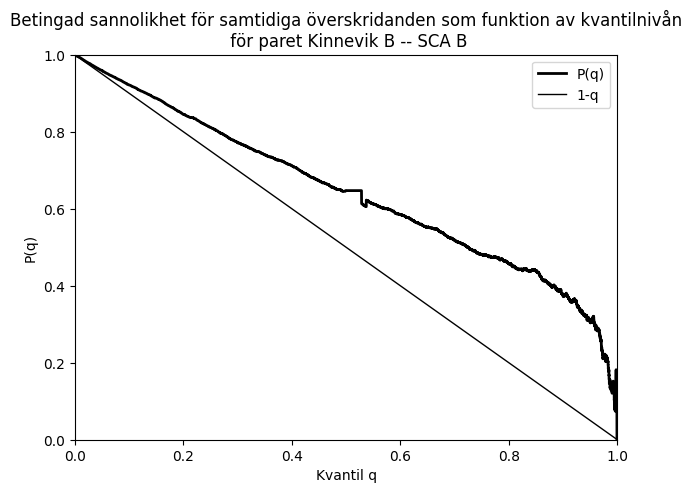

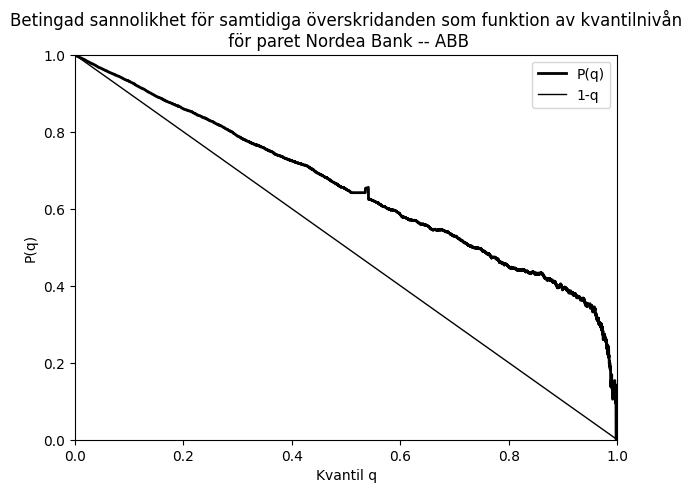

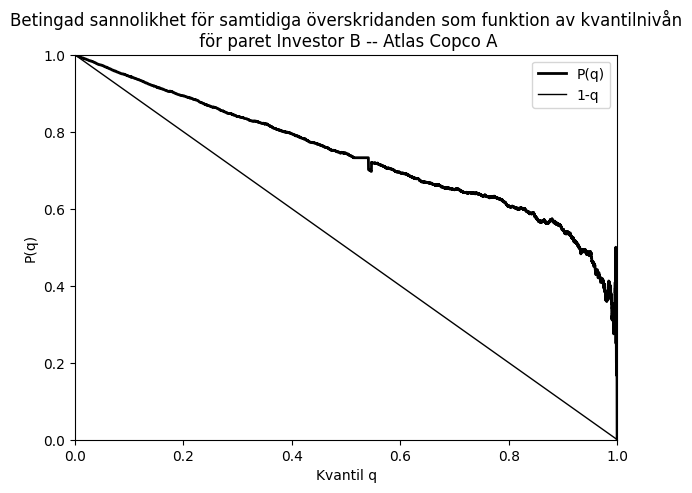

In [11]:
#Illustrativa plottar för konvergens och bivariata dagliga avkastningar
    # Försöker efterlikna den illustration i Poon et al. av konvergensen
def daily_stock_returns_scatterplots(logrets, x_name, y_name):

    pair_data = logrets[[x_name, y_name]].dropna()

    x = pair_data[x_name]
    y = pair_data[y_name]

    plt.figure(figsize=(5,5))
    plt.scatter(x*100, y*100, alpha=0.2, s=8)
    plt.axis("equal")
    plt.xlabel(f"{x_name} (%)")
    plt.ylabel(f"{y_name} (%)")
    plt.title(f"{x_name} vs {y_name} (daily log-losses, %)")

    plt.axhline(0, linestyle="--", linewidth=0.5)
    plt.axvline(0, linestyle="--", linewidth=0.5)

    plt.show()

def P_q(u_x, u_y, q):
    mask = u_x > q
    if mask.sum() == 0:
        return np.nan
    return np.mean(u_y[mask] > q)


def plot_Pq(u_x, u_y, pair):

    qs_plot = np.linspace(0, 0.9999, 50000)

    P_q_vals = [P_q(u_x, u_y, q) for q in qs_plot]
    indep_line = 1 - qs_plot

    plt.figure(figsize=(7, 5))

    plt.plot(qs_plot, P_q_vals, color="black", linewidth=2, label="P(q)")
    plt.plot(qs_plot, indep_line, color="black", linewidth=1, linestyle="-", label="1-q")

    plt.xlabel("Kvantil q")
    plt.ylabel("P(q)")
    plt.title("Betingad sannolikhet för samtidiga överskridanden som funktion av kvantilnivån"\
              "\n" + f" för paret {pair}")
    # plt.title(f"P(q) = Pr(U_{y_name} > q | U_{x_name} > q)")

    plt.xlim(0, 1)
    plt.ylim(0, 1)

    plt.legend()
    plt.show()

# Plotta oberoende par med tydligast skillnad och ett beroende par.
# Endast för illustrationen i rapportens Appendix.
indep_pair_1 = oberoende_df.loc[oberoende_df["chi_bar_hat"] == chibar_max].index[0]
indep_pair_2 = oberoende_df.loc[oberoende_df["chi_bar_hat"] == chibar_min].index[0]
some_pair = beroende_df.loc[beroende_df["chi_hat"] == chi_max].index[0] # bara för att se skillnaden
for pair in [indep_pair_1, indep_pair_2, some_pair]:
    x_name, y_name = complete_pairs[pair]
    F_x = marginal_cdfs[x_name][0]
    F_y = marginal_cdfs[y_name][0]
    plot_Pq(F_x, F_y, pair)

In [12]:
# Modellparametrar, beräkning. Allt enligt Poon et al.

gammas = {}
rhos = {}
for key in parameter_results.keys():
  if parameter_results[key]["chi_hat"] == 0:
    rhos[key] = parameter_results[key]["chi_bar_hat"]
  else:
    gammas[key] = np.log(2-parameter_results[key]["chi_hat"])/np.log(2)
gamma_df = pd.DataFrame(gammas, index=["gamma"])
rho_df = pd.DataFrame(rhos, index=["rho"])

In [13]:
# Simulering/modellering av likformiga variabler (F_X,F_Y) från de bivariata logistiska- och gaussiska modellerna
rng = np.random.default_rng(seed=123) # Sätter ett seed så att resultaten blir reproducerbara

extra = {}
sample = {}
model = {}
for key in parameter_results.keys():
  if parameter_results[key]["chi_hat"] == 0:
    rho = rhos[key]

    mean = [0,0]
    cov = [[1, rho],[rho, 1]]

    z = rng.multivariate_normal(mean,\
                                                    cov,\
                                                    size=100000,\
                                                    check_valid='warn',\
                                                    tol=1e-8)

    u = stats.norm.cdf(z[:, 0]) # transformerar till exp(-1/S) = F_X = U_X
    v = stats.norm.cdf(z[:, 1]) # transformerar till exp(-1/T) = F_Y = U_Y
    utemp = u
    vtemp = v
    sample[key] = np.stack([u, v], axis=-1)
    model[key] = "Gaussian"

  else:

    gamma = gammas[key]

    cop = GumbelCopula(theta = 1/gamma)
    sample[key] = cop.rvs(nobs = 100000, random_state= rng)
    model[key] = "Logistic"

In [14]:
# Invers avbildning tillbaka till (X,Y)
def inverse_margin(U, logret, threshold, F_u, xi, sigma):
  """
  Inverterar U_X -> X med redan skattad marginalmodell:
  - empirisk invers under threshold
  - GPD-invers över threshold
  """
  logret = np.asarray(pd.Series(logret).dropna(), dtype=float)
  U = np.asarray(U, dtype=float)
  U = np.clip(U, 1e-12, 1 - 1e-12) # För att undvika log(0) exempelvis

  x = np.empty_like(U, dtype=float)

  body = U < F_u # booleanmaskning för värden under Fs värde i tröskeln
  tail = ~body    # booleanmaskning för värden över Fs värde i tröskeln

  if np.any(body):
      x[body] = np.quantile(logret, U[body])

  if np.any(tail):
      u_tail = U[tail]

      if abs(xi) > 1e-10:
          x[tail] = threshold + (sigma / xi) * (
              ((1 - u_tail) / (1 - F_u)) ** (-xi) - 1
          )
      else:
          x[tail] = threshold - sigma * np.log((1 - u_tail) / (1 - F_u))

  return x

## Här exekveras ovan funktion

XY = {}
for pair_name, (x_name, y_name) in complete_pairs.items():

  pair_data = df_logloss[[x_name, y_name]].dropna()
  ux = u_optimal[x_name]["Threshold (log)"]
  uy = u_optimal[y_name]["Threshold (log)"]

  x_data = pair_data[x_name].values
  y_data = pair_data[y_name].values

  U_X = sample[pair_name][:, 0]
  U_Y = sample[pair_name][:, 1]

  # här måste du plocka rätt redan-skattade parametrar ur din struktur
  xi_x = marginal_cdfs[x_name][1]
  sigma_x = marginal_cdfs[x_name][2]
  xi_y = marginal_cdfs[y_name][1]
  sigma_y = marginal_cdfs[y_name][2]

  # F evaluerad i tröskeln
  F_ux = empirical_cdf_eval(x_data, ux)
  F_uy = empirical_cdf_eval(y_data, uy)

  X_sim = inverse_margin(U_X, x_data, ux, F_ux, xi_x, sigma_x)
  Y_sim = inverse_margin(U_Y, y_data, uy, F_uy, xi_y, sigma_y)

  XY[pair_name] = np.column_stack([X_sim, Y_sim])

In [15]:
def minimize_ca_grid(X: pd.Series, Y: pd.Series, ux: float, uy: float, alpha: float, n_grid=1000):
  """
  Enkel grid-sökning som hittar bästa viktsfaktorn a.
  Optimerar ca under kravet: ca > a*ux + (1-a)*uy
  """
  
  x = np.asarray(X)
  y = np.asarray(Y)
  
  a_grid = np.linspace(0.001, 0.999, n_grid)
  
  best_ca = np.inf
  best_a = None
  
  for a in a_grid:
    # Beräkna portföljförlusten
    P = a * x + (1 - a) * y
    ca = np.quantile(P, 1 - alpha)
    
    # Beräkna kravtröskeln
    threshold = a * ux + (1 - a) * uy
    
    # Kontrollera kravet och om det är bättre än tidigare
    if ca > threshold and ca < best_ca: # Om ja, uppdatera bästa ca och a
      best_ca = ca
      best_a = a
  
  # Fallback om inget a uppfyllde kravet
  if best_a is None:
    print(f"Varning: Inget a uppfyllde kravet för paret. Använder fallback a=0.5")
    best_a = 0.5
    P = best_a * x + (1 - best_a) * y
    best_ca = np.quantile(P, 1 - alpha)
    string = "fail"
  else:
    string = "success"
  
  return float(best_a), float(best_ca), string

#============================================================================
# Transformation till vanliga returns
def exp_of_logloss(logval):
  return (1 - np.exp( - logval) ) # observera tecknet

#============================================================================

def result_summary(XY: dict, u_optimal: dict, complete_pairs: dict, parameter_results: dict, model: dict, alpha: float):
  # Resultatssammanställning
  results = {}
  P_dict = {}

  for key in XY.keys():
    x, y = zip(*XY[key])

    # Transformera tillbaka från logloss till procentuell förlust
    x = exp_of_logloss(np.array(x))
    y = exp_of_logloss(np.array(y))
    ux = exp_of_logloss(u_optimal[complete_pairs[key][0]]["Threshold (log)"])
    uy = exp_of_logloss(u_optimal[complete_pairs[key][1]]["Threshold (log)"])


    # Minimera ca över a
    a, ca, string = minimize_ca_grid(x, y, ux, uy, alpha)

    # Beräkna procentuell förlust kopplat till VaR-nivån
    perc_loss = 100*float(ca)

    #Spara P för det optimala a
    P = a * x + (1-a) * y
    P_dict[key] = P

    chi = parameter_results[key]["chi_hat"]
    chi_bar = parameter_results[key]["chi_bar_hat"]
    se_chi_bar = parameter_results[key]["se_chi_bar"]

    results[key] = {
        "Modell": model[key],
        "chi_bar_hat": np.round(chi_bar,2) if chi_bar + 1.96*se_chi_bar < 1 else 1.00,
        "chi_hat": np.round(chi, 2),
        "(1-alpha)-kvantil ca": np.round(ca, 4),
        "Optimerad vikt": np.round(a, 3),
        "Förlust (%)": np.round(perc_loss, 2)
    }
  return results, P_dict, string

===========================| alpha = 0.01 |===========================

In [16]:
# Resultatssammanställning med alpha=0.01
alpha = 0.01
results, P_dict, string = result_summary(XY, u_optimal, complete_pairs, parameter_results, model, alpha)
results = pd.DataFrame(results).T

# Exportera till csv
results.to_csv(f"results_alpha_{alpha}.csv", index=True)

# Resultatssammanställning med alpha=0.01
print(f" Antalet par: {len(results)}")
results.style.set_caption(f"Resultatssammanställning givet α = {alpha}")

 Antalet par: 45


,Modell,chi_bar_hat,chi_hat,(1-alpha)-kvantil ca,Optimerad vikt,Förlust (%)
Kinnevik B -- Investor B,Gaussian,0.490000,0,0.040400,0.236000,4.040000
Kinnevik B -- SEB A,Logistic,1.000000,0.170000,0.046700,0.464000,4.670000
Kinnevik B -- Nordea Bank,Logistic,1.000000,0.160000,0.045100,0.448000,4.510000
Kinnevik B -- Castellum,Logistic,1.000000,0.170000,0.043600,0.363000,4.360000
Kinnevik B -- Skanska B,Logistic,1.000000,0.160000,0.042300,0.362000,4.230000
Kinnevik B -- ABB,Gaussian,0.590000,0,0.052900,0.382000,5.290000
Kinnevik B -- Atlas Copco A,Logistic,1.000000,0.180000,0.045700,0.386000,4.570000
Kinnevik B -- Boliden,Gaussian,0.580000,0,0.057000,0.683000,5.700000
Kinnevik B -- SCA B,Gaussian,0.600000,0,0.040500,0.105000,4.050000
Investor B -- SEB A,Logistic,1.000000,0.210000,0.039500,0.700000,3.950000


In [17]:
gaussian_results = results[results["Modell"] == "Gaussian"]
logistic_results = results[results["Modell"] == "Logistic"]

# Medelvärde av chi_bar_hat för de par som klassificerats som asymptotiskt oberoende
mean_chi_bar_gaussian = np.round(gaussian_results["chi_bar_hat"].mean(), 3)
median_chi_bar_gaussian = np.round(gaussian_results["chi_bar_hat"].median(), 3)
print(f"Medelvärde av chi_bar_hat för alla gaussiska par (tre värdesiffror): {mean_chi_bar_gaussian}")
print(f"Median av chi_bar_hat för alla gaussiska par (tre värdesiffror): {median_chi_bar_gaussian}")

# Displayar antal par med asymptotisk oberoende i gaussiska modellen ihop med antalet par
gaussian_results.style.set_caption(f"Antal par med asymptotisk oberoende: {len(gaussian_results)}")

Medelvärde av chi_bar_hat för alla gaussiska par (tre värdesiffror): 0.52
Median av chi_bar_hat för alla gaussiska par (tre värdesiffror): 0.53


,Modell,chi_bar_hat,chi_hat,(1-alpha)-kvantil ca,Optimerad vikt,Förlust (%)
Kinnevik B -- Investor B,Gaussian,0.490000,0,0.040400,0.236000,4.040000
Kinnevik B -- ABB,Gaussian,0.590000,0,0.052900,0.382000,5.290000
Kinnevik B -- Boliden,Gaussian,0.580000,0,0.057000,0.683000,5.700000
Kinnevik B -- SCA B,Gaussian,0.600000,0,0.040500,0.105000,4.050000
SEB A -- ABB,Gaussian,0.550000,0,0.051000,0.488000,5.100000
SEB A -- SCA B,Gaussian,0.580000,0,0.040900,0.209000,4.090000
Nordea Bank -- ABB,Gaussian,0.370000,0,0.045300,0.549000,4.530000
Castellum -- ABB,Gaussian,0.450000,0,0.045000,0.558000,4.500000
Castellum -- SCA B,Gaussian,0.500000,0,0.038300,0.253000,3.830000
Skanska B -- Boliden,Gaussian,0.520000,0,0.047300,0.819000,4.730000


In [18]:
# Expected Shortfall och VaR för alla portföljer
risk_measures = {}
for key in P_dict.keys():
  P = P_dict[key]
  ca = results.loc[key, "(1-alpha)-kvantil ca"]

  mask = P > ca
  ES = float(np.mean(P[mask]))
  VaR = float(ca)
  risk_measures[key] = {
      "Expected Shortfall (%)": np.round(ES*100, 2),
      "Value at Risk (%)": np.round(VaR*100, 2)
  }

risk_measures = pd.DataFrame(risk_measures).T

===========================| alpha = 0.001 |===========================

In [19]:
# Resultatssammanställning med alpha=0.001
alpha = 0.001
results2, P_dict2, string2 = result_summary(XY, u_optimal, complete_pairs, parameter_results, model, alpha)
results2 = pd.DataFrame(results2).T

# Exportera till csv
results2.to_csv(f"results_alpha_{alpha}.csv", index=True)

# Resultatssammanställning med alpha=0.001
print(f" Antalet par: {len(results2)}")
results2.style.set_caption(f"Resultatssammanställning givet α = {alpha}")

 Antalet par: 45


,Modell,chi_bar_hat,chi_hat,(1-alpha)-kvantil ca,Optimerad vikt,Förlust (%)
Kinnevik B -- Investor B,Gaussian,0.490000,0,0.068600,0.285000,6.860000
Kinnevik B -- SEB A,Logistic,1.000000,0.170000,0.101000,0.538000,10.100000
Kinnevik B -- Nordea Bank,Logistic,1.000000,0.160000,0.082100,0.261000,8.210000
Kinnevik B -- Castellum,Logistic,1.000000,0.170000,0.077300,0.376000,7.730000
Kinnevik B -- Skanska B,Logistic,1.000000,0.160000,0.081600,0.238000,8.160000
Kinnevik B -- ABB,Gaussian,0.590000,0,0.114700,0.593000,11.470000
Kinnevik B -- Atlas Copco A,Logistic,1.000000,0.180000,0.082800,0.214000,8.280000
Kinnevik B -- Boliden,Gaussian,0.580000,0,0.105600,0.537000,10.560000
Kinnevik B -- SCA B,Gaussian,0.600000,0,0.070500,0.142000,7.050000
Investor B -- SEB A,Logistic,1.000000,0.210000,0.073600,0.915000,7.360000


In [20]:
gaussian_results = results2[results2["Modell"] == "Gaussian"]
logistic_results = results2[results2["Modell"] == "Logistic"]

# Medelvärde av chi_bar_hat för de par som klassificerats som asymptotiskt oberoende
mean_chi_bar_gaussian = np.round(gaussian_results["chi_bar_hat"].mean(), 3)
median_chi_bar_gaussian = np.round(gaussian_results["chi_bar_hat"].median(), 3)
print(f"Medelvärde av chi_bar_hat för alla gaussiska par (tre värdesiffror): {mean_chi_bar_gaussian}")
print(f"Median av chi_bar_hat för alla gaussiska par (tre värdesiffror): {median_chi_bar_gaussian}")

# Displayar antal par med asymptotisk oberoende i gaussiska modellen ihop med antalet par
gaussian_results.style.set_caption(f"Antal par med asymptotisk oberoende: {len(gaussian_results)}")

Medelvärde av chi_bar_hat för alla gaussiska par (tre värdesiffror): 0.52
Median av chi_bar_hat för alla gaussiska par (tre värdesiffror): 0.53


,Modell,chi_bar_hat,chi_hat,(1-alpha)-kvantil ca,Optimerad vikt,Förlust (%)
Kinnevik B -- Investor B,Gaussian,0.490000,0,0.068600,0.285000,6.860000
Kinnevik B -- ABB,Gaussian,0.590000,0,0.114700,0.593000,11.470000
Kinnevik B -- Boliden,Gaussian,0.580000,0,0.105600,0.537000,10.560000
Kinnevik B -- SCA B,Gaussian,0.600000,0,0.070500,0.142000,7.050000
SEB A -- ABB,Gaussian,0.550000,0,0.104900,0.683000,10.490000
SEB A -- SCA B,Gaussian,0.580000,0,0.072400,0.149000,7.240000
Nordea Bank -- ABB,Gaussian,0.370000,0,0.082300,0.693000,8.230000
Castellum -- ABB,Gaussian,0.450000,0,0.077200,0.834000,7.720000
Castellum -- SCA B,Gaussian,0.500000,0,0.062100,0.443000,6.210000
Skanska B -- Boliden,Gaussian,0.520000,0,0.087000,0.732000,8.700000


In [21]:
# Expected Shortfall och VaR för alla portföljer
risk_measures2 = {}
for key in P_dict.keys():
  P = P_dict2[key]
  ca = results2.loc[key, "(1-alpha)-kvantil ca"]

  mask = P > ca
  ES = float(np.mean(P[mask]))
  VaR = float(ca)
  risk_measures2[key] = {
      "Expected Shortfall (%)": np.round(ES*100, 2),
      "Value at Risk (%)": np.round(VaR*100, 2)
  }

risk_measures2 = pd.DataFrame(risk_measures2).T

In [22]:
k = 5 # top k performing shares
##---------- alpha = 0.01

# exporting the results in a merged way
greatest_ca = results['Förlust (%)'].sort_values(ascending=True).head(k)
index = greatest_ca.index

top_performers = results.loc[index]
risk_measures_top = risk_measures.loc[index]
portfolio_df1 = top_performers.join(risk_measures_top).drop(columns=["(1-alpha)-kvantil ca"])

# Exportera till csv
portfolio_df1.to_csv(f"portfolio_df1.csv", index=True)

##---------- alpha = 0.001


# exporting the results in a merged way
greatest_ca = results2['Förlust (%)'].sort_values(ascending=True).head(k)
index = greatest_ca.index

top_performers2 = results2.loc[index]
risk_measures_top2 = risk_measures2.loc[index]
portfolio_df2 = top_performers2.join(risk_measures_top2).drop(columns=["(1-alpha)-kvantil ca"])

# Exportera till csv
portfolio_df2.to_csv(f"portfolio_df2.csv", index=True)

In [23]:
display(portfolio_df1)
display(portfolio_df2)

,Modell,chi_bar_hat,chi_hat,Optimerad vikt,Förlust (%),Expected Shortfall (%),Value at Risk (%)
Investor B -- SCA B,Logistic,1.0,0.18,0.657,3.51,4.73,3.51
Investor B -- Castellum,Logistic,1.0,0.17,0.738,3.69,4.81,3.69
Nordea Bank -- SCA B,Logistic,1.0,0.17,0.365,3.71,5.04,3.71
Atlas Copco A -- SCA B,Logistic,1.0,0.19,0.171,3.76,5.05,3.76
Skanska B -- SCA B,Logistic,1.0,0.17,0.204,3.77,4.99,3.77


,Modell,chi_bar_hat,chi_hat,Optimerad vikt,Förlust (%),Expected Shortfall (%),Value at Risk (%)
Investor B -- Castellum,Logistic,1.0,0.17,0.627,6.1,7.72,6.10
Investor B -- SCA B,Logistic,1.0,0.18,0.471,6.17,8.07,6.17
Castellum -- SCA B,Gaussian,0.5,0,0.443,6.21,7.69,6.21
Skanska B -- SCA B,Logistic,1.0,0.17,0.396,6.45,8.50,6.45
Atlas Copco A -- SCA B,Logistic,1.0,0.19,0.32,6.62,8.04,6.62


================================= APPENDIX ===================================

Nedan cell är genererad med AI, i syfte att illustrera en bivariat extremregion R, på vår begäran om hur området ska se ut.

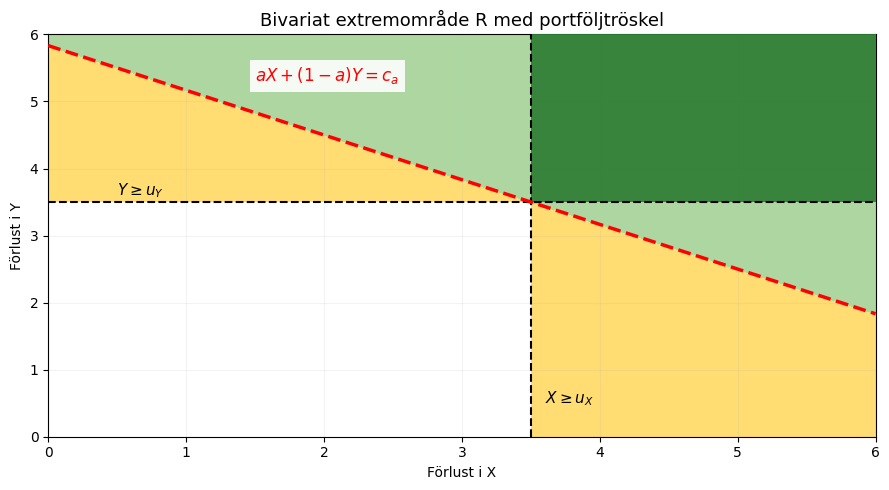

In [24]:
# Thresholds
ux, uy = 3.5, 3.5
a = 0.4
ca = a*ux + (1-a)*uy

# Grid
x = np.linspace(0, 6, 500)
y = np.linspace(0, 6, 500)
X, Y = np.meshgrid(x, y)

# Regions
bulk   = (X < ux) & (Y < uy)
side   = ((X >= ux) & (Y < uy)) | ((X < ux) & (Y >= uy))
corner = (X >= ux) & (Y >= uy)

# Portfolio line region
portfolio_tail = (a*X + (1-a)*Y >= ca)

# Plot
plt.figure(figsize=(9, 5))

# 1. Side regions (gul)
plt.contourf(X, Y, side, levels=[0.5, 1],
             colors=['#FFD54F'], alpha=0.8, zorder=1)

# 2. Portfolio exceedance (ljusgrön) MEN EJ joint tail
mid_region = portfolio_tail & (~corner)
plt.contourf(X, Y, mid_region, levels=[0.5, 1],
             colors=['#A5D6A7'], alpha=0.9, zorder=2)

# 3. Joint tail (grön)
plt.contourf(X, Y, corner, levels=[0.5, 1],
             colors=['#2E7D32'], alpha=0.95, zorder=3)

# Threshold lines
plt.axvline(ux, color='black', linestyle='--', linewidth=1.5, zorder=4)
plt.axhline(uy, color='black', linestyle='--', linewidth=1.5, zorder=4)

# Portfolio line
plt.contour(X, Y, a*X + (1-a)*Y, levels=[ca],
            colors=['red'], linestyles='--', linewidths=2.5, zorder=5)

# Labels
plt.text(ux + 0.1, 0.5, r'$X \geq u_X$', fontsize=11)
plt.text(0.5, uy + 0.1, r'$Y \geq u_Y$', fontsize=11)

plt.text(1.5, 5.3, r'$aX + (1-a)Y = c_a$', color='red', fontsize=12,
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='none'))

# Styling
plt.title("Bivariat extremområde R med portföljtröskel", fontsize=13)
plt.xlabel("Förlust i X")
plt.ylabel("Förlust i Y")

plt.xlim(0, 6)
plt.ylim(0, 6)

plt.grid(alpha=0.15)
plt.tight_layout()

plt.show()